# Notebook 07: Process Noise Recalibration

## Motivation

In Notebook 04, the **process noise** $\sigma$ added to the MC Dropout trajectories was calibrated on the **full historical series of Li-Lee first differences** (1957-2020). This approach has a conceptual flaw: **double-counting**.

The historical $\sigma$ includes *all* the variability in mortality changes — but the LSTM has already learned to predict a significant portion of that variability. When we add the full historical $\sigma$ as process noise on top of the LSTM's stochastic predictions (which already incorporate model uncertainty via MC Dropout), we are counting the "predictable" component of variability twice.

**The correct approach**: calibrate $\sigma$ on the **model's residuals** — the difference between what the LSTM predicts and what actually happened. This isolates the *irreducible* uncertainty that the model cannot capture, which is the true aleatoric/process noise.

## Methodology

1. **Walk-forward one-step-ahead prediction**: For each time step $t$ where we have at least `lookback` prior observations, use the champion model (deterministically, `training=False`) to predict $\Delta K_{t}$.
2. **Residual computation**: $r_t = \Delta K_t^{observed} - \Delta K_t^{predicted}$ for all eligible time steps.
3. **New $\sigma$**: $\sigma_{residual} = \text{std}(r_t)$ — this is the process noise that the model *cannot* explain.
4. **Comparison**: Old $\sigma$ (historical) vs new $\sigma$ (residual) — quantify the double-counting.
5. **Re-forecast**: Re-run the full stochastic pipeline (MC Dropout + new $\sigma$) and compare CI widths and SCR.

## Why This Is Correct

In a dual uncertainty framework:
- **Epistemic uncertainty** (what the model doesn't know) is captured by MC Dropout — different dropout masks produce different predictions.
- **Aleatoric/process uncertainty** (intrinsic randomness of the future) should be calibrated on what the model *cannot* predict — i.e., its residuals.

Using historical $\sigma$ instead of residual $\sigma$ inflates the aleatoric component by including the "predictable signal" that the LSTM already captures. Over 30 recursive steps, this inflation compounds, producing unrealistically wide confidence intervals.


## 7.1: Setup & Asset Loading

In [11]:
import sys
sys.path.append('../src')
from reproducibility import set_seed
set_seed(42)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle, os, logging, warnings
warnings.filterwarnings('ignore')

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
tf.get_logger().setLevel(logging.ERROR)
from tensorflow import keras
import joblib

from style_config import set_style, save_dual, COUNTRIES, COUNTRY_COLORS
set_style("notebook")

PROCESSED_DIR = "../data/processed/"
MODELS_DIR = "../models/"
FIGURES_DIR = "../reports/figures/"
os.makedirs(FIGURES_DIR, exist_ok=True)

# Load champion model and scaler
champion_model = keras.models.load_model(
    os.path.join(MODELS_DIR, "ainn_champion.keras"),
    compile=False
)
scaler = joblib.load(os.path.join(MODELS_DIR, "scaler_joint.pkl"))

# Load training metadata
with open(os.path.join(PROCESSED_DIR, "training_meta.pkl"), "rb") as f:
    meta = pickle.load(f)

LOOKBACK = meta["lookback"]
N_FEATURES = meta["n_features"]
TRAIN_SPLIT_IDX = meta["train_split_idx"]

# Load Li-Lee parameters
with open(os.path.join(PROCESSED_DIR, "li_lee_params.pkl"), "rb") as f:
    bundle = pickle.load(f)

feature_matrices = bundle["feature_matrices"]
common_factors = bundle["common_factors"]
specific_factors = bundle["specific_factors"]
YEARS = bundle["metadata"]["years"]
AGES = bundle["metadata"]["ages"]
N_AGES = len(AGES)

print(f"Champion model loaded: lookback={LOOKBACK}, features={N_FEATURES}")
print(f"Architecture: {[l.name for l in champion_model.layers]}")
print(f"\nLi-Lee parameters loaded.")
print(f"Years: {YEARS[0]}-{YEARS[-1]}, Ages: {AGES[0]}-{AGES[-1]}")
print(f"Train split idx: {TRAIN_SPLIT_IDX} (training diffs: 0-{TRAIN_SPLIT_IDX-1}, val: {TRAIN_SPLIT_IDX}-63)")
print(f"Cluster: {list(COUNTRIES.keys())}")

Champion model loaded: lookback=15, features=8
Architecture: ['input_layer_100', 'lstm_200', 'dropout_200', 'lstm_201', 'dropout_201', 'dense_100']

Li-Lee parameters loaded.
Years: 1956-2020, Ages: 0-90
Train split idx: 55 (training diffs: 0-54, val: 55-63)
Cluster: ['CHE', 'SWE', 'NOR', 'DEUTW', 'NLD', 'JPN']


## 7.2: Walk-Forward One-Step-Ahead Residuals

For each sex, we compute one-step-ahead predictions on the **full dataset** (training + validation) using a walk-forward approach:

- For each time step $t \geq$ `lookback`, we take the preceding `lookback` observations as input.
- We predict $\Delta K_t$ deterministically (`training=False`, no dropout).
- We compute the residual: $r_t = \Delta K_t^{observed} - \Delta K_t^{predicted}$.

**Note**: We use `training=False` (dropout disabled) because we want the model's *best estimate* prediction, not a stochastic sample. The residuals should reflect the model's systematic prediction error, not the dropout-induced variability (which is already captured by MC Dropout in the forecast).

In [12]:
def compute_walkforward_residuals(model, scaler, feature_matrix_7d, sex, lookback=LOOKBACK):
    """
    Compute one-step-ahead residuals using walk-forward prediction.
    
    Args:
        model: Trained Keras model.
        scaler: Fitted StandardScaler (expects 8 features: 7 factors + sex indicator).
        feature_matrix_7d: np.ndarray of shape (n_diffs, 7) — Li-Lee first differences.
        sex: 'male' or 'female' (for the sex indicator).
        lookback: Number of prior steps used as input.
    
    Returns:
        residuals: np.ndarray of shape (n_eligible_steps, 8) — observed minus predicted.
        predictions: np.ndarray of shape (n_eligible_steps, 8) — model predictions (original scale).
        actuals: np.ndarray of shape (n_eligible_steps, 8) — observed values (original scale).
        eligible_years: list of year labels for the eligible steps.
    """
    sex_indicator = 0.0 if sex == 'male' else 1.0
    
    # Build full 8D feature matrix (7 factors + sex indicator)
    data_8d = np.column_stack([
        feature_matrix_7d,
        np.full(len(feature_matrix_7d), sex_indicator)
    ])
    
    # Scale the full dataset
    data_scaled = scaler.transform(data_8d)
    
    n_total = len(data_8d)
    residuals_list = []
    predictions_list = []
    actuals_list = []
    eligible_years = []
    
    for t in range(lookback, n_total):
        # Input: lookback steps ending at t-1
        input_seq = data_scaled[t - lookback : t]  # shape: (lookback, 8)
        
        # Predict step t deterministically (no dropout)
        inp_tensor = tf.convert_to_tensor(input_seq[np.newaxis, ...], dtype=tf.float32)
        pred_scaled = model(inp_tensor, training=False).numpy().reshape(N_FEATURES)
        
        # Inverse transform to original scale
        pred_orig = scaler.inverse_transform(pred_scaled.reshape(1, -1)).reshape(N_FEATURES)
        actual_orig = data_8d[t]  # Already in original scale
        
        residual = actual_orig - pred_orig
        
        residuals_list.append(residual)
        predictions_list.append(pred_orig)
        actuals_list.append(actual_orig)
        # t is an index into the first-differences array (64 entries: years 1957-2020)
        # t=0 corresponds to year 1957 (diff between 1956 and 1957)
        eligible_years.append(YEARS[t + 1])  # +1 because diffs are offset by 1 from YEARS
    
    return (
        np.array(residuals_list),
        np.array(predictions_list),
        np.array(actuals_list),
        eligible_years
    )

print("Computing walk-forward residuals...")
print(f"  Eligible predictions: steps {LOOKBACK} to 63 = {64 - LOOKBACK} predictions per sex")
print(f"  (Years: {YEARS[LOOKBACK+1]}-{YEARS[-1]})")

res_male, pred_male, act_male, years_male = compute_walkforward_residuals(
    champion_model, scaler, feature_matrices['male'], 'male'
)
res_female, pred_female, act_female, years_female = compute_walkforward_residuals(
    champion_model, scaler, feature_matrices['female'], 'female'
)

print(f"\nResiduals computed:")
print(f"  Male:   {res_male.shape} (steps, features), years {years_male[0]}-{years_male[-1]}")
print(f"  Female: {res_female.shape} (steps, features), years {years_female[0]}-{years_female[-1]}")

Computing walk-forward residuals...
  Eligible predictions: steps 15 to 63 = 49 predictions per sex
  (Years: 1972-2020)

Residuals computed:
  Male:   (49, 8) (steps, features), years 1972-2020
  Female: (49, 8) (steps, features), years 1972-2020


## 7.3: Old vs New $\sigma$ — Quantifying the Double-Counting

We now compare:
- **$\sigma_{historical}$**: std of full Li-Lee first differences (1957-2020) — the old approach from Notebook 04.
- **$\sigma_{residual}$**: std of the model's walk-forward residuals — the corrected approach.

The ratio $\sigma_{residual} / \sigma_{historical}$ tells us how much of the historical variability the model has learned to predict. A ratio < 1 means the model captures some signal; the closer to 0, the more signal it captures.

In [13]:
def compute_historical_sigma(feature_matrix_7d, sex):
    """Compute sigma as in the original NB04 (full historical first diffs)."""
    sex_indicator = 0.0 if sex == 'male' else 1.0
    data = np.column_stack([
        feature_matrix_7d,
        np.full(len(feature_matrix_7d), sex_indicator)
    ])
    # Note: feature_matrices are already first differences (64 rows)
    # In NB04, the code does np.diff(data, axis=0) — but the data IS already diffs.
    # Let's reproduce exactly what NB04 does.
    hist_diffs = np.diff(data, axis=0)  # Second differences! But this is what NB04 does.
    return np.std(hist_diffs, axis=0)

# Wait — let me verify what NB04 actually computes.
# In NB04 Cell 4, `inverse_and_add_noise`:
#   data = np.column_stack([feature_matrices[sex], np.full(...)])
#   hist_diffs = np.diff(data, axis=0)
#   process_std = np.std(hist_diffs, axis=0)
#
# feature_matrices[sex] has shape (64, 7) — these ARE first differences of K_t.
# So np.diff() on first differences gives SECOND differences.
# This means the historical sigma is actually based on second differences,
# not first differences. This is important for the comparison.

# Reproduce exactly
sigma_hist_male = compute_historical_sigma(feature_matrices['male'], 'male')
sigma_hist_female = compute_historical_sigma(feature_matrices['female'], 'female')

# New sigma: std of residuals
sigma_res_male = np.std(res_male, axis=0)
sigma_res_female = np.std(res_female, axis=0)

# Comparison table
factor_names = ['Kt (common)', 'CHE', 'SWE', 'NOR', 'DEUTW', 'NLD', 'JPN', 'Sex indicator']

print("=" * 90)
print("MALE — Process Noise Comparison")
print("=" * 90)
print(f"{'Factor':<20} {'σ_historical':>12} {'σ_residual':>12} {'Ratio':>8} {'Reduction':>10}")
print("-" * 62)
for i, name in enumerate(factor_names):
    h, r = sigma_hist_male[i], sigma_res_male[i]
    ratio = r / h if h > 0 else float('inf')
    reduction = (1 - ratio) * 100
    print(f"{name:<20} {h:>12.4f} {r:>12.4f} {ratio:>8.3f} {reduction:>9.1f}%")

print()
print("=" * 90)
print("FEMALE — Process Noise Comparison")
print("=" * 90)
print(f"{'Factor':<20} {'σ_historical':>12} {'σ_residual':>12} {'Ratio':>8} {'Reduction':>10}")
print("-" * 62)
for i, name in enumerate(factor_names):
    h, r = sigma_hist_female[i], sigma_res_female[i]
    ratio = r / h if h > 0 else float('inf')
    reduction = (1 - ratio) * 100
    print(f"{name:<20} {h:>12.4f} {r:>12.4f} {ratio:>8.3f} {reduction:>9.1f}%")

print()
print("Key metric — Kt (common factor) sigma reduction:")
print(f"  Male:   {sigma_hist_male[0]:.4f} → {sigma_res_male[0]:.4f} ({(1 - sigma_res_male[0]/sigma_hist_male[0])*100:.1f}% reduction)")
print(f"  Female: {sigma_hist_female[0]:.4f} → {sigma_res_female[0]:.4f} ({(1 - sigma_res_female[0]/sigma_hist_female[0])*100:.1f}% reduction)")

MALE — Process Noise Comparison
Factor               σ_historical   σ_residual    Ratio  Reduction
--------------------------------------------------------------
Kt (common)                5.9888       2.8026    0.468      53.2%
CHE                        1.4912       1.1082    0.743      25.7%
SWE                        0.0567       0.7552   13.315   -1231.5%
NOR                        8.2675       5.7943    0.701      29.9%
DEUTW                      0.7344       0.4112    0.560      44.0%
NLD                        5.3519       2.5722    0.481      51.9%
JPN                        4.6360       2.3326    0.503      49.7%
Sex indicator              0.0000       0.0725      inf      -inf%

FEMALE — Process Noise Comparison
Factor               σ_historical   σ_residual    Ratio  Reduction
--------------------------------------------------------------
Kt (common)                9.0816       3.6356    0.400      60.0%
CHE                        4.1662       1.7567    0.422      57.8%
SWE

## 7.4: Residual Diagnostics

Before using the new $\sigma$, we verify that the residuals behave like noise (approximately zero mean, no obvious structure).

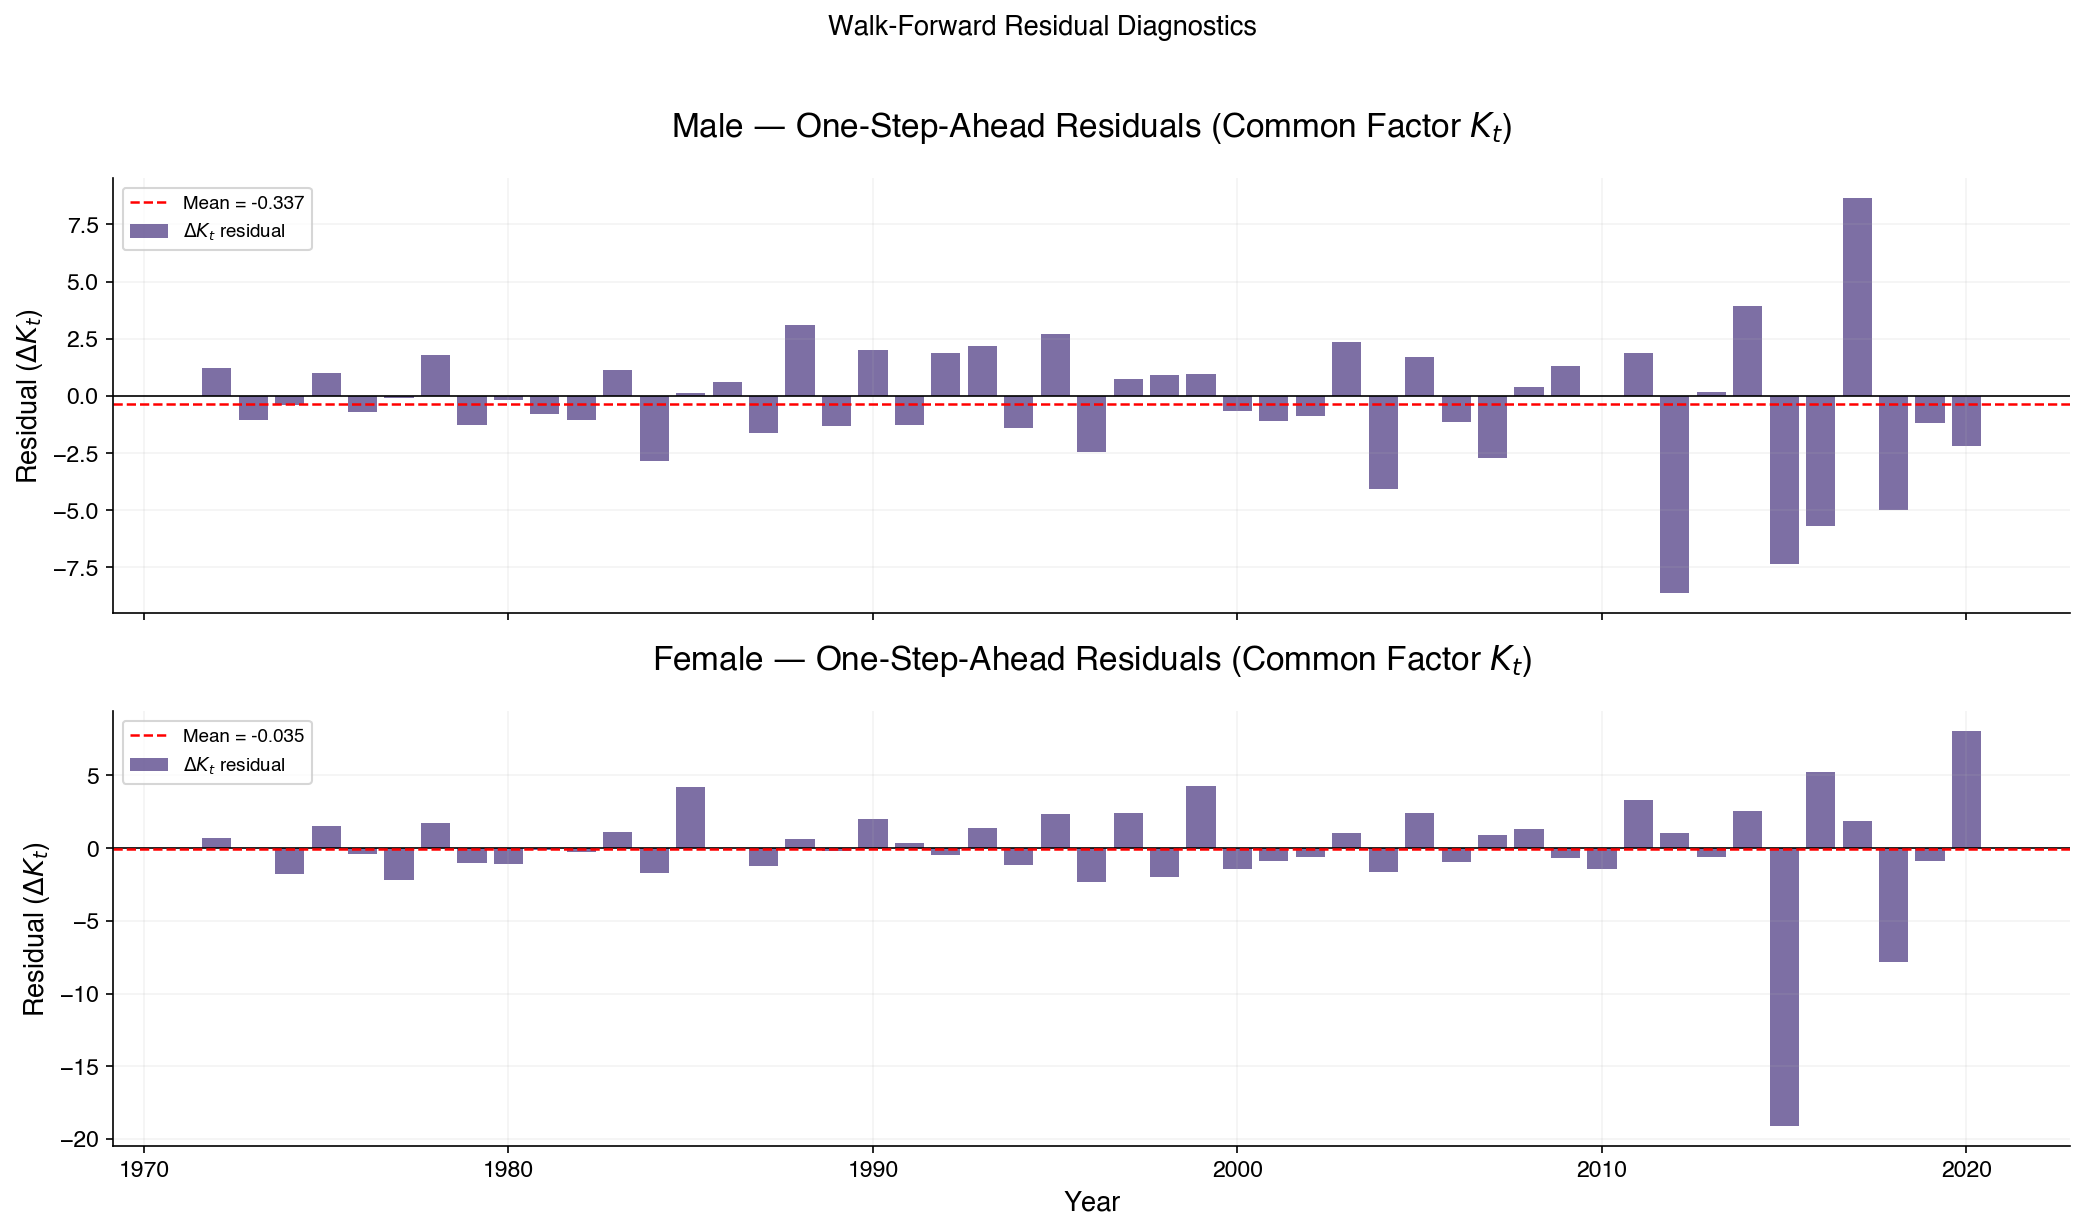

Residual summary (Kt, common factor):
  Male  — mean: -0.3366, std: 2.8026, min: -8.6311, max: 8.6609
  Female — mean: -0.0346, std: 3.6356, min: -19.1284, max: 8.0451


In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for sex_idx, (sex, residuals, years_list) in enumerate([
    ('Male', res_male, years_male), ('Female', res_female, years_female)
]):
    ax = axes[sex_idx]
    # Plot residuals for the common factor (column 0)
    ax.bar(years_list, residuals[:, 0], color=COUNTRY_COLORS['CHE'], alpha=0.7, label='$\\Delta K_t$ residual')
    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.axhline(y=residuals[:, 0].mean(), color='red', linewidth=1.2, linestyle='--',
              label=f'Mean = {residuals[:, 0].mean():.3f}')
    ax.set_ylabel('Residual ($\\Delta K_t$)')
    ax.set_title(f'{sex} — One-Step-Ahead Residuals (Common Factor $K_t$)')
    ax.legend(loc='upper left', fontsize=9)

axes[-1].set_xlabel('Year')
fig.suptitle('Walk-Forward Residual Diagnostics', fontsize=13, y=1.02)
plt.tight_layout()
save_dual(fig, "fig20_residual_diagnostics")
plt.show()

# Summary stats
print("Residual summary (Kt, common factor):")
print(f"  Male  — mean: {res_male[:, 0].mean():.4f}, std: {res_male[:, 0].std():.4f}, min: {res_male[:, 0].min():.4f}, max: {res_male[:, 0].max():.4f}")
print(f"  Female — mean: {res_female[:, 0].mean():.4f}, std: {res_female[:, 0].std():.4f}, min: {res_female[:, 0].min():.4f}, max: {res_female[:, 0].max():.4f}")

## 7.5: Re-Run Stochastic Forecast with Corrected $\sigma$

We now re-run the full stochastic forecasting pipeline from Notebook 04, replacing only the process noise calibration. Everything else remains identical:
- Same champion model
- Same MC Dropout (1,000 simulations)
- Same initial sequences
- Same MBC computation
- Same observation-anchored $e_0$ reconstruction

The only change: $\sigma_{process} = \sigma_{residual}$ instead of $\sigma_{historical}$.

In [15]:
N_SIMULATIONS = 1000
N_YEARS_AHEAD = 30  # 2021-2050

# ============================================================
# Step 1: Prepare initial sequences (identical to NB04)
# ============================================================

def get_initial_sequence(sex, lookback=LOOKBACK):
    sex_indicator = 0.0 if sex == 'male' else 1.0
    data = np.column_stack([
        feature_matrices[sex],
        np.full(len(feature_matrices[sex]), sex_indicator)
    ])
    data_scaled = scaler.transform(data)
    return data_scaled[-lookback:]

init_male = get_initial_sequence('male')
init_female = get_initial_sequence('female')

# ============================================================
# Step 2: MC Dropout forecast (identical to NB04)
# ============================================================

def forecast_mcd(model, initial_sequence, n_steps=N_YEARS_AHEAD, n_sims=N_SIMULATIONS):
    n_features = initial_sequence.shape[-1]
    all_sims = np.zeros((n_sims, n_steps, n_features))
    for sim in range(n_sims):
        current_seq = initial_sequence.copy()
        for step in range(n_steps):
            inp = tf.convert_to_tensor(current_seq[np.newaxis, ...], dtype=tf.float32)
            pred = model(inp, training=True).numpy().reshape(n_features)
            all_sims[sim, step, :] = pred
            current_seq = np.roll(current_seq, -1, axis=0)
            current_seq[-1] = pred
        if (sim + 1) % 200 == 0:
            print(f"  MC Dropout: {sim+1}/{n_sims} simulations done.")
    return all_sims

print("Running MC Dropout forecast (Male)...")
sims_male_scaled = forecast_mcd(champion_model, init_male)
print("\nRunning MC Dropout forecast (Female)...")
sims_female_scaled = forecast_mcd(champion_model, init_female)
print(f"\nForecast shapes: {sims_male_scaled.shape}")

# ============================================================
# Step 3: Inverse transform + CORRECTED process noise
# ============================================================

def inverse_and_add_noise_corrected(sims_scaled, sex, sigma_residual):
    """
    Inverse-transform scaled predictions and add RESIDUAL-CALIBRATED process noise.
    
    Key difference from NB04: sigma is from model residuals, not historical diffs.
    This avoids double-counting the variability already captured by the LSTM.
    """
    n_sims, n_steps, n_features = sims_scaled.shape
    flat = sims_scaled.reshape(-1, n_features)
    flat_orig = scaler.inverse_transform(flat)
    sims_orig = flat_orig.reshape(n_sims, n_steps, n_features)
    
    sims_with_noise = sims_orig.copy()
    for t in range(n_steps):
        noise = np.random.normal(0, sigma_residual, size=(n_sims, n_features))
        sims_with_noise[:, t, :] += noise
    
    return sims_with_noise

sims_male_orig = inverse_and_add_noise_corrected(sims_male_scaled, 'male', sigma_res_male)
sims_female_orig = inverse_and_add_noise_corrected(sims_female_scaled, 'female', sigma_res_female)

print(f"\nSimulations with corrected noise: {sims_male_orig.shape}")
print(f"Process noise σ (Male, Kt):   {sigma_res_male[0]:.4f} (was {sigma_hist_male[0]:.4f})")
print(f"Process noise σ (Female, Kt): {sigma_res_female[0]:.4f} (was {sigma_hist_female[0]:.4f})")

Running MC Dropout forecast (Male)...
  MC Dropout: 200/1000 simulations done.
  MC Dropout: 400/1000 simulations done.
  MC Dropout: 600/1000 simulations done.
  MC Dropout: 800/1000 simulations done.
  MC Dropout: 1000/1000 simulations done.

Running MC Dropout forecast (Female)...
  MC Dropout: 200/1000 simulations done.
  MC Dropout: 400/1000 simulations done.
  MC Dropout: 600/1000 simulations done.
  MC Dropout: 800/1000 simulations done.
  MC Dropout: 1000/1000 simulations done.

Forecast shapes: (1000, 30, 8)

Simulations with corrected noise: (1000, 30, 8)
Process noise σ (Male, Kt):   2.8026 (was 5.9888)
Process noise σ (Female, Kt): 3.6356 (was 9.0816)


In [16]:
# ============================================================
# Step 4: Level reconstruction (identical to NB04)
# ============================================================

def integrate_to_levels(sims_diffs_orig, sex):
    sex_indicator = 0.0 if sex == 'male' else 1.0
    data = np.column_stack([
        feature_matrices[sex],
        np.full(len(feature_matrices[sex]), sex_indicator)
    ])
    last_level_2020 = data[-1]
    n_sims, n_steps, n_features = sims_diffs_orig.shape
    levels = np.zeros((n_sims, n_steps + 1, n_features))
    levels[:, 0, :] = last_level_2020
    for t in range(1, n_steps + 1):
        levels[:, t, :] = levels[:, t-1, :] + sims_diffs_orig[:, t-1, :]
    return levels

levels_male = integrate_to_levels(sims_male_orig, 'male')
levels_female = integrate_to_levels(sims_female_orig, 'female')

forecast_years = np.array([YEARS[-1]] + list(range(YEARS[-1]+1, YEARS[-1]+N_YEARS_AHEAD+1)))
kt_male_sims = levels_male[:, :, 0]
kt_female_sims = levels_female[:, :, 0]

print(f"Level arrays: {levels_male.shape}")
print(f"Kt male range (2050):   [{kt_male_sims[:,-1].min():.2f}, {kt_male_sims[:,-1].max():.2f}]")
print(f"Kt female range (2050): [{kt_female_sims[:,-1].min():.2f}, {kt_female_sims[:,-1].max():.2f}]")

# ============================================================
# Step 5: MBC (identical to NB04)
# ============================================================

def apply_mbc(sims_diffs_orig, sex):
    data = np.column_stack([
        feature_matrices[sex],
        np.full(len(feature_matrices[sex]), 0.0 if sex == 'male' else 1.0)
    ])
    train_diffs = np.diff(data[:TRAIN_SPLIT_IDX], axis=0)
    mu_li_lee = train_diffs.mean(axis=0)
    mu_ainn = sims_diffs_orig.mean(axis=(0, 1))
    bias = mu_li_lee - mu_ainn
    sims_mbc = sims_diffs_orig + bias[np.newaxis, np.newaxis, :]
    return sims_mbc, bias

sims_male_mbc, bias_male = apply_mbc(sims_male_orig, 'male')
sims_female_mbc, bias_female = apply_mbc(sims_female_orig, 'female')
levels_male_mbc = integrate_to_levels(sims_male_mbc, 'male')
levels_female_mbc = integrate_to_levels(sims_female_mbc, 'female')

print(f"\nBias correction vectors:")
print(f"  Male bias (Kt):   {bias_male[0]:.4f}")
print(f"  Female bias (Kt): {bias_female[0]:.4f}")

Level arrays: (1000, 31, 8)
Kt male range (2050):   [-100.85, 12.54]
Kt female range (2050): [-100.73, 22.09]

Bias correction vectors:
  Male bias (Kt):   0.8711
  Female bias (Kt): 1.9232


In [17]:
# ============================================================
# Step 6: Observation-Anchored e0 Reconstruction (identical to NB04)
# ============================================================

def calculate_e0(log_mx):
    mx = np.exp(log_mx)
    qx = 1.0 - np.exp(-mx)
    qx[-1] = 1.0
    px = 1.0 - qx
    lx = np.concatenate(([1.0], np.cumprod(px[:-1])))
    lx_extended = np.append(lx, 0.0)
    e0 = np.sum((lx_extended[:-1] + lx_extended[1:]) / 2.0)
    return e0

def reconstruct_e0_anchored(sims_diffs_orig, sex):
    Bx = common_factors[sex]['Bx']
    n_sims = sims_diffs_orig.shape[0]
    n_steps = sims_diffs_orig.shape[1]
    n_countries = len(COUNTRIES)
    
    delta_kt_all = sims_diffs_orig[:, :, 0]
    cumulative_delta_kt = np.cumsum(delta_kt_all, axis=1)
    zeros = np.zeros((n_sims, 1))
    cumulative_delta_kt = np.concatenate([zeros, cumulative_delta_kt], axis=1)
    
    e0_all = np.zeros((n_sims, n_steps + 1, n_countries))
    
    for c_idx, code in enumerate(COUNTRIES.keys()):
        log_mx_matrix = np.load(os.path.join(PROCESSED_DIR, f"{code}_log_mx_{sex}.npy"))
        log_mx_2020 = log_mx_matrix[:, -1]
        for s in range(n_sims):
            for t in range(n_steps + 1):
                log_mx_t = log_mx_2020 + Bx * cumulative_delta_kt[s, t]
                e0_all[s, t, c_idx] = calculate_e0(log_mx_t)
    
    return e0_all

print("Reconstructing e0 (Observation-Anchored, corrected σ)...")
print("  Male, without MBC...")
e0_male = reconstruct_e0_anchored(sims_male_orig, 'male')
print("  Male, with MBC...")
e0_male_mbc = reconstruct_e0_anchored(sims_male_mbc, 'male')
print("  Female, without MBC...")
e0_female = reconstruct_e0_anchored(sims_female_orig, 'female')
print("  Female, with MBC...")
e0_female_mbc = reconstruct_e0_anchored(sims_female_mbc, 'female')

print(f"\ne0 arrays: {e0_male.shape}")

# Sanity check
che_idx = list(COUNTRIES.keys()).index('CHE')
print(f"\nSanity check (CHE, 2020):")
print(f"  Male:   {e0_male[:, 0, che_idx].mean():.2f}")
print(f"  Female: {e0_female[:, 0, che_idx].mean():.2f}")

Reconstructing e0 (Observation-Anchored, corrected σ)...
  Male, without MBC...
  Male, with MBC...
  Female, without MBC...
  Female, with MBC...

e0 arrays: (1000, 31, 6)

Sanity check (CHE, 2020):
  Male:   80.26
  Female: 83.58


## 7.6: Results Comparison — Old vs New $\sigma$

We now compare the key downstream metrics between the original (NB04) and corrected (NB07) forecasts.

In [18]:
# Load original NB04 results for comparison
with open(os.path.join(PROCESSED_DIR, "forecasting_assets.pkl"), "rb") as f:
    old_assets = pickle.load(f)

old_e0_male = old_assets['e0_male']
old_e0_female = old_assets['e0_female']
old_e0_male_mbc = old_assets['e0_male_mbc']
old_e0_female_mbc = old_assets['e0_female_mbc']

# Build comparison table
comparison_rows = []
for c_idx, (code, name) in enumerate(COUNTRIES.items()):
    for sex, old_e0, new_e0, old_e0_m, new_e0_m in [
        ('Male', old_e0_male, e0_male, old_e0_male_mbc, e0_male_mbc),
        ('Female', old_e0_female, e0_female, old_e0_female_mbc, e0_female_mbc)
    ]:
        old_2020 = old_e0[:, 0, c_idx].mean()
        new_2020 = new_e0[:, 0, c_idx].mean()
        
        old_med = np.percentile(old_e0[:, -1, c_idx], 50)
        new_med = np.percentile(new_e0[:, -1, c_idx], 50)
        
        old_p5 = np.percentile(old_e0[:, -1, c_idx], 2.5)
        old_p95 = np.percentile(old_e0[:, -1, c_idx], 97.5)
        new_p5 = np.percentile(new_e0[:, -1, c_idx], 2.5)
        new_p95 = np.percentile(new_e0[:, -1, c_idx], 97.5)
        
        old_ci = old_p95 - old_p5
        new_ci = new_p95 - new_p5
        
        comparison_rows.append({
            'Country': name, 'Sex': sex,
            'e0(2020)': round(new_2020, 2),
            'Old Median(2050)': round(old_med, 2),
            'New Median(2050)': round(new_med, 2),
            'Old 95%CI Width': round(old_ci, 2),
            'New 95%CI Width': round(new_ci, 2),
            'CI Reduction': f"{(1 - new_ci/old_ci)*100:.1f}%"
        })

df_comparison = pd.DataFrame(comparison_rows)
print("=" * 110)
print("COMPARISON: Old σ (Historical) vs New σ (Residual)")
print("=" * 110)
print(df_comparison.to_string(index=False))

COMPARISON: Old σ (Historical) vs New σ (Residual)
     Country    Sex  e0(2020)  Old Median(2050)  New Median(2050)  Old 95%CI Width  New 95%CI Width CI Reduction
 Switzerland   Male     80.26             82.01             82.04             7.73             3.77        51.3%
 Switzerland Female     83.58             86.04             85.99             7.88             3.15        60.0%
      Sweden   Male     79.94             81.69             81.72             7.75             3.80        51.0%
      Sweden Female     82.93             85.55             85.49             8.35             3.40        59.2%
      Norway   Male     80.57             82.25             82.28             7.42             3.64        51.0%
      Norway Female     83.27             85.79             85.73             8.04             3.27        59.3%
West Germany   Male     78.28             80.28             80.32             8.85             4.36        50.8%
West Germany Female     82.20             85.

## 7.7: Updated SCR Estimates

Recompute VaR 99.5% (Solvency II) and ES 99.0% (SST) with the corrected σ.

In [19]:
scr_rows = []

for c_idx, (code, name) in enumerate(COUNTRIES.items()):
    for sex, e0_arr in [('Male', e0_male), ('Female', e0_female)]:
        e0_2050 = e0_arr[:, -1, c_idx]
        median_e0 = np.percentile(e0_2050, 50)
        
        # VaR 99.5% (Solvency II): 99.5th percentile
        var_995 = np.percentile(e0_2050, 99.5)
        scr_var = var_995 - median_e0
        
        # ES 99.0% (SST): mean of top 1%
        threshold_99 = np.percentile(e0_2050, 99)
        tail_values = e0_2050[e0_2050 >= threshold_99]
        es_990 = tail_values.mean() if len(tail_values) > 0 else var_995
        scr_es = es_990 - median_e0
        
        scr_rows.append({
            'Country': name, 'Sex': sex,
            'Median e0 (2050)': round(median_e0, 2),
            'SCR VaR 99.5%': f'+{scr_var:.3f}',
            'SCR ES 99.0%': f'+{scr_es:.3f}',
        })

df_scr = pd.DataFrame(scr_rows)
print("=" * 80)
print("UPDATED SCR ESTIMATES (Corrected σ, AINN without MBC)")
print("=" * 80)
print(df_scr.to_string(index=False))

# Compare with old SCR (from NB06)
print("\n--- Comparison with NB04/06 results (old σ) ---")
print("  Old SCR CHE Male (ES 99.0%):   +3.760 years")
print("  Old SCR CHE Female (ES 99.0%): +2.919 years")
che_male_e0 = e0_male[:, -1, che_idx]
che_female_e0 = e0_female[:, -1, che_idx]
new_scr_m = np.mean(che_male_e0[che_male_e0 >= np.percentile(che_male_e0, 99)]) - np.percentile(che_male_e0, 50)
new_scr_f = np.mean(che_female_e0[che_female_e0 >= np.percentile(che_female_e0, 99)]) - np.percentile(che_female_e0, 50)
print(f"  New SCR CHE Male (ES 99.0%):   +{new_scr_m:.3f} years")
print(f"  New SCR CHE Female (ES 99.0%): +{new_scr_f:.3f} years")

UPDATED SCR ESTIMATES (Corrected σ, AINN without MBC)
     Country    Sex  Median e0 (2050) SCR VaR 99.5% SCR ES 99.0%
 Switzerland   Male             82.04        +1.973       +2.167
 Switzerland Female             85.99        +1.585       +1.606
      Sweden   Male             81.72        +2.011       +2.210
      Sweden Female             85.49        +1.735       +1.758
      Norway   Male             82.28        +1.918       +2.108
      Norway Female             85.73        +1.660       +1.683
West Germany   Male             80.32        +2.324       +2.556
West Germany Female             84.99        +1.895       +1.920
 Netherlands   Male             81.02        +2.136       +2.349
 Netherlands Female             84.82        +1.948       +1.974
       Japan   Male             82.19        +1.969       +2.162
       Japan Female             86.90        +1.291       +1.308

--- Comparison with NB04/06 results (old σ) ---
  Old SCR CHE Male (ES 99.0%):   +3.760 years
  Old 

## 7.8: Save Updated Assets

Persist the corrected forecasting results for downstream use.

In [20]:
# Save corrected forecasting assets
corrected_assets = {
    # Kt level trajectories
    "kt_male_sims": kt_male_sims,
    "kt_female_sims": kt_female_sims,
    "kt_male_mbc": levels_male_mbc[:, :, 0],
    "kt_female_mbc": levels_female_mbc[:, :, 0],
    # e0 trajectories
    "e0_male": e0_male,
    "e0_female": e0_female,
    "e0_male_mbc": e0_male_mbc,
    "e0_female_mbc": e0_female_mbc,
    # Metadata
    "forecast_years": forecast_years,
    "n_sims": N_SIMULATIONS,
    "n_years_ahead": N_YEARS_AHEAD,
    "bias_male": bias_male,
    "bias_female": bias_female,
    # Corrected process noise
    "process_std_male": sigma_res_male,
    "process_std_female": sigma_res_female,
    "process_std_male_old": sigma_hist_male,
    "process_std_female_old": sigma_hist_female,
    "countries": list(COUNTRIES.keys()),
    # Residual diagnostics
    "residuals_male": res_male,
    "residuals_female": res_female,
    "residual_years_male": years_male,
    "residual_years_female": years_female,
    "calibration_method": "walk_forward_residuals",
}

with open(os.path.join(PROCESSED_DIR, "forecasting_assets_corrected.pkl"), "wb") as f:
    pickle.dump(corrected_assets, f)

# Save comparison tables
df_comparison.to_csv(os.path.join(PROCESSED_DIR, "sigma_comparison.csv"), index=False)
df_scr.to_csv(os.path.join(PROCESSED_DIR, "scr_corrected.csv"), index=False)

print("Corrected assets saved:")
print(f"  {PROCESSED_DIR}forecasting_assets_corrected.pkl")
print(f"  {PROCESSED_DIR}sigma_comparison.csv")
print(f"  {PROCESSED_DIR}scr_corrected.csv")
print(f"\nNotebook 07 complete.")
print(f"Next: evaluate whether CI/SCR are now in reasonable range, then proceed to Step 2 (ensemble).")

Corrected assets saved:
  ../data/processed/forecasting_assets_corrected.pkl
  ../data/processed/sigma_comparison.csv
  ../data/processed/scr_corrected.csv

Notebook 07 complete.
Next: evaluate whether CI/SCR are now in reasonable range, then proceed to Step 2 (ensemble).
